# GISLR — does each sign have a kinematic "pattern"? Intra- vs inter-gloss similarity (TODO §3.8)

**Dataset-stage diagnostic. No model is trained.** The user's question (2026-09-25): compute a small set of
interpretable variables per clip and check two things across **all 250 glosses**. Are clips of the same
gloss similar? Are different glosses dissimilar? If both hold, each sign generalizes to a pattern.

Per clip (`sb.recognize.patterns.clip_descriptors`, the user's 7 steps):
1. every point minus the mid-shoulder point (reference point);
2. ÷ the clip's median shoulder width (scale);
3. elbow, shoulder and wrist angles, each side;
4. distances: hand ↔ hand, each hand ↔ face (nose tip), each hand ↔ chest (mid-shoulder);
5. null frames dropped (no shoulders, or no hand at all); a hand missing in a kept frame stays NaN;
6. variance of displacement, velocity, acceleration and jerk (derivative orders 0–3) of every point per
   axis, and of every pair distance;
7. touch counts: hand–hand and hand–face contact onsets.

Each variable set is computed in four axis settings the user asked for (**`x` only, `y` only, `z` only,
`xyz`**) plus `xy`, the setting every model here uses. Angles need at least 2 axes, so the single-axis runs
have no angle family.

**Tests**, per axis setting × variable family:
- **intra / inter**: mean cosine similarity of two clips of the same gloss vs two clips of different
  glosses (standardized variables);
- **separable glosses**: share of glosses whose own clips are more alike than they are to the closest
  other gloss;
- **silhouette** (cosine, glosses as clusters; 1 = perfect patterns, 0 = overlapping, < 0 = wrong);
- **nearest template**: one mean-descriptor template per gloss from `train.csv`, every `test.csv` clip
  assigned to the most similar template. Top-1/top-5 against chance of 0.4%. This checks whether the
  pattern generalizes, with no fitted weights.
- **Fisher ratio** per variable: between-gloss variance / within-gloss variance.

| artifact | path |
|---|---|
| descriptors, one parquet per chunk (resumable) | `data/cache/gislr/sign_patterns/descriptors/chunk_<k>.parquet` |
| every test result | `data/cache/gislr/sign_patterns/results.json`, `results.csv` |
| per-variable Fisher ratios | `data/cache/gislr/sign_patterns/fisher.csv` |
| per-gloss table | `data/cache/gislr/sign_patterns/per_gloss.csv` |
| figures | `data/cache/gislr/sign_patterns/assets/*.png` |

**Resumable:** a chunk whose parquet exists is skipped; §3 reads only the parquets.
Related earlier work: `docs/reports/feature-discriminability.md` (a trained logistic probe on 15 glosses)
and `pair-similarity.md`. This notebook covers all 250 glosses, the user's variables, and uses no fitted model.

## 1. Setup

In [1]:
# ============================================================
# Imports, tunables, paths
# ============================================================
import json
import os
from concurrent.futures import ProcessPoolExecutor
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, gislr_dir
from sb.recognize import patterns as PT

AXES = ("x", "y", "z", "xy", "xyz")  # the user's x / y / z / xyz, plus xy (what the models use)
TOUCH_THR = 0.12      # contact below 0.12 shoulder widths (~5 cm); ends above 1.5x that
CHUNK = 5000          # clips per resumable chunk
WORKERS = 12          # processes for descriptor extraction
FAMILY_SETS = {       # what each test row compares
    "angle": ("angle",),
    "distance": ("distance",),
    "touch": ("touch",),
    "angle+distance+touch": ("angle", "distance", "touch"),  # the user's variables combined
    "kinematics": ("kinematics",),
    "all": ("angle", "distance", "touch", "kinematics"),
}

DATA = gislr_dir()
OUT = CACHE_DIR / "gislr" / "sign_patterns"
DESC = OUT / "descriptors"
ASSETS = OUT / "assets"
for d in (DESC, ASSETS):
    d.mkdir(parents=True, exist_ok=True)
CLIPS = pd.concat([pd.read_csv(DATA / "train.csv"), pd.read_csv(DATA / "test.csv")], ignore_index=True)
print(f"GISLR: {DATA}\n{len(CLIPS)} clips ({(CLIPS.split == 'train').sum()} train / {(CLIPS.split == 'test').sum()} test), "
      f"{CLIPS.sign.nunique()} glosses\nresults -> {OUT}")

GISLR: C:\Users\user2\.cache\kagglehub\datasets\bracu23101281\gislr-stratified\versions\1
94477 clips (75581 train / 18896 test), 250 glosses
results -> C:\Users\user2\repository\data\cache\gislr\sign_patterns


## 2. Descriptors for every clip (steps 1–7)

In [2]:
# ============================================================
# Every clip x every axis setting; one parquet per chunk (resumable)
# ============================================================
fn = partial(PT.file_descriptors, axes=AXES, touch_thr=TOUCH_THR)
chunks = [(k, CLIPS.iloc[s:s + CHUNK]) for k, s in enumerate(range(0, len(CLIPS), CHUNK))]
todo = [(k, c) for k, c in chunks if not (DESC / f"chunk_{k:03d}.parquet").exists()]
bar = tqdm(total=sum(len(c) for _, c in todo), desc="descriptors")
with ProcessPoolExecutor(WORKERS) as ex:
    for k, c in todo:
        rows = []
        for r in ex.map(fn, [str(DATA / p) for p in c.npz_relpath], chunksize=64):
            rows.append(r)
            bar.update()
        t = pd.DataFrame(rows, index=c.index)
        t.insert(0, "sign", c.sign.to_numpy())
        t.insert(1, "split", c.split.to_numpy())
        t.insert(2, "participant_id", c.participant_id.to_numpy())
        tmp = DESC / f"chunk_{k:03d}.tmp.parquet"
        t.to_parquet(tmp)
        os.replace(tmp, DESC / f"chunk_{k:03d}.parquet")
bar.close()
TABLE = pd.concat([pd.read_parquet(p) for p in sorted(DESC.glob("chunk_*.parquet"))]).sort_index()
assert len(TABLE) == len(CLIPS)
print(TABLE.shape, "· null frames dropped:",
      f"{1 - TABLE['xyz|meta:n_kept'].sum() / TABLE['xyz|meta:n_frames'].sum():.1%}",
      "· clips with no usable frame:", int((TABLE['xyz|meta:n_kept'] == 0).sum()))

descriptors: 0it [00:00, ?it/s]

(94477, 590) · null frames dropped: 39.1% · clips with no usable frame: 0


## 3. Intra- vs inter-gloss similarity, per axis setting × variable family

`similarity_report` runs on all `train.csv` clips, and `nearest_template` goes train → test. `dominant` is
the same test after relabeling each clip so "right" means the hand seen more often. GISLR has left-handed
signers, whose clips otherwise look like a different sign.

In [3]:
# ============================================================
# Every test; results.json / results.csv
# ============================================================
TABLE = pd.concat([pd.read_parquet(p) for p in sorted(DESC.glob("chunk_*.parquet"))]).sort_index()
usable = TABLE["xyz|meta:n_kept"] > 0
tr = (TABLE.split == "train") & usable
te = (TABLE.split == "test") & usable
rows, per_gloss, fisher = [], {}, {}
for axes in tqdm(AXES, desc="axis settings"):
    for hand in ("as labeled", "dominant"):
        t = TABLE if hand == "as labeled" else PT.dominant_swap(TABLE, axes)[0]
        sub = t[[c for c in t.columns if c.startswith(f"{axes}|")]]
        sub.columns = [c.split("|", 1)[1] for c in sub.columns]
        for fam, fams in FAMILY_SETS.items():
            X, cols = PT.feature_matrix(sub, fams)
            if not cols:
                continue  # angles on a single axis
            y = t.sign.to_numpy()
            rep = PT.similarity_report(X[tr.to_numpy()], y[tr.to_numpy()])
            nt = PT.nearest_template(X[tr.to_numpy()], y[tr.to_numpy()], X[te.to_numpy()], y[te.to_numpy()])
            F = PT.fisher_ratio(X[tr.to_numpy()], y[tr.to_numpy()])
            rows.append({"axes": axes, "hand": hand, "family": fam, "n_vars": len(cols),
                         **{k: v for k, v in rep.items() if k != "per_gloss"}, **nt,
                         "fisher_median": float(np.median(F)), "fisher_max": float(F.max())})
            if hand == "dominant":
                per_gloss[f"{axes}/{fam}"] = rep["per_gloss"]
                fisher[f"{axes}/{fam}"] = dict(zip(cols, F.tolist()))
RES = pd.DataFrame(rows)
RES.to_csv(OUT / "results.csv", index=False)
tmp = OUT / "results.tmp.json"
tmp.write_text(json.dumps({"results": rows, "per_gloss": per_gloss}, indent=1))
os.replace(tmp, OUT / "results.json")
pd.DataFrame([{"setting": k, "variable": v, "fisher": f} for k, d in fisher.items() for v, f in d.items()]) \
    .to_csv(OUT / "fisher.csv", index=False)
show = ["axes", "hand", "family", "n_vars", "intra", "inter", "nearest_inter", "frac_glosses_separable",
        "silhouette", "top1", "top5", "fisher_median"]
print(RES[show].to_string(index=False, float_format="{:.3f}".format))

axis settings:   0%|          | 0/5 [00:00<?, ?it/s]

axes       hand               family  n_vars  intra  inter  nearest_inter  frac_glosses_separable  silhouette  top1  top5  fisher_median
   x as labeled             distance      20  0.164  0.035          0.210                   0.032      -0.204 0.015 0.069          0.042
   x as labeled                touch       5  0.035  0.024          0.052                   0.012      -0.159 0.004 0.023          0.010
   x as labeled angle+distance+touch      25  0.099  0.019          0.130                   0.020      -0.141 0.014 0.070          0.039
   x as labeled           kinematics      44  0.125  0.089          0.172                   0.032      -0.161 0.013 0.057          0.019
   x as labeled                  all      69  0.099  0.038          0.125                   0.060      -0.118 0.024 0.093          0.023
   x   dominant             distance      10  0.306  0.066          0.396                   0.020      -0.453 0.020 0.086          0.062
   x   dominant                touch     

## 4. Which variables carry the pattern (Fisher ratio, dominant-hand `xyz`)

In [4]:
# ============================================================
# Top and bottom variables by between/within-gloss variance
# ============================================================
FI = pd.read_csv(OUT / "fisher.csv")
f = FI[FI.setting == "xyz/all"].sort_values("fisher", ascending=False)
f["family"] = f.variable.str.split(":").str[0]
print("top 20:\n" + f.head(20).to_string(index=False, float_format="{:.3f}".format))
print("\nmedian Fisher ratio by family:\n" + f.groupby("family").fisher.describe()[["count", "50%", "max"]].to_string())
by_axis = (FI[FI.setting.str.endswith("/all")].assign(axes=lambda d: d.setting.str.split("/").str[0])
           .groupby("axes").fisher.median())
print("\nmedian Fisher ratio by axis setting (all variables):\n" + by_axis.to_string())

top 20:
setting                           variable  fisher     family
xyz/all                 touch:rh_face_frac   0.910      touch
xyz/all                touch:rh_face_count   0.529      touch
xyz/all              distance:rh_face_mean   0.495   distance
xyz/all kinematics:rh_index_tip_x_disp_var   0.170 kinematics
xyz/all  kinematics:rh_centroid_x_disp_var   0.163 kinematics
xyz/all      kinematics:r_elbow_y_disp_var   0.157 kinematics
xyz/all      kinematics:r_wrist_y_disp_var   0.147 kinematics
xyz/all  kinematics:rh_centroid_y_disp_var   0.123 kinematics
xyz/all                 angle:r_wrist_mean   0.110      angle
xyz/all kinematics:rh_index_tip_y_disp_var   0.097 kinematics
xyz/all      kinematics:r_wrist_x_disp_var   0.085 kinematics
xyz/all             distance:rh_chest_mean   0.070   distance
xyz/all  kinematics:rh_index_tip_x_vel_var   0.065 kinematics
xyz/all          distance:rh_face_disp_var   0.061   distance
xyz/all             angle:r_wrist_disp_var   0.060      angle


## 5. Per gloss: which signs have a tight, distinct pattern

In [5]:
# ============================================================
# Per-gloss silhouette and nearest rival (dominant-hand xyz, the user's combined variables)
# ============================================================
R = json.loads((OUT / "results.json").read_text())["per_gloss"]
key = "xyz/angle+distance+touch"
PG = pd.DataFrame(R[key]).sort_values("silhouette", ascending=False)
PG["margin"] = PG["intra"] - PG["nearest_inter"]
PG.to_csv(OUT / "per_gloss.csv", index=False)
cols = ["gloss", "silhouette", "intra", "nearest_inter", "nearest_gloss", "margin"]
print(f"{key}: glosses with positive mean silhouette {(PG.silhouette > 0).mean():.1%}, "
      f"intra > nearest rival {(PG.margin > 0).mean():.1%}")
print("\nmost pattern-like:\n" + PG[cols].head(12).to_string(index=False, float_format="{:.3f}".format))
print("\nleast pattern-like:\n" + PG[cols].tail(12).to_string(index=False, float_format="{:.3f}".format))

xyz/angle+distance+touch: glosses with positive mean silhouette 0.0%, intra > nearest rival 7.2%

most pattern-like:
  gloss  silhouette  intra  nearest_inter nearest_gloss  margin
   shhh      -0.032  0.228          0.209        orange   0.019
 minemy      -0.044  0.149          0.132          have   0.017
   have      -0.046  0.159          0.145        animal   0.014
  clown      -0.057  0.220          0.210          duck   0.010
   chin      -0.063  0.178          0.181          shhh  -0.003
 jacket      -0.067  0.145          0.141          have   0.004
 animal      -0.073  0.141          0.145          have  -0.003
   lion      -0.075  0.096          0.074           hat   0.021
   frog      -0.077  0.194          0.203          shhh  -0.009
fireman      -0.078  0.130          0.094           boy   0.036
   duck      -0.081  0.213          0.211          bird   0.002
   bird      -0.081  0.209          0.211          duck  -0.002

least pattern-like:
      gloss  silhouette  intra

## 6. Figures

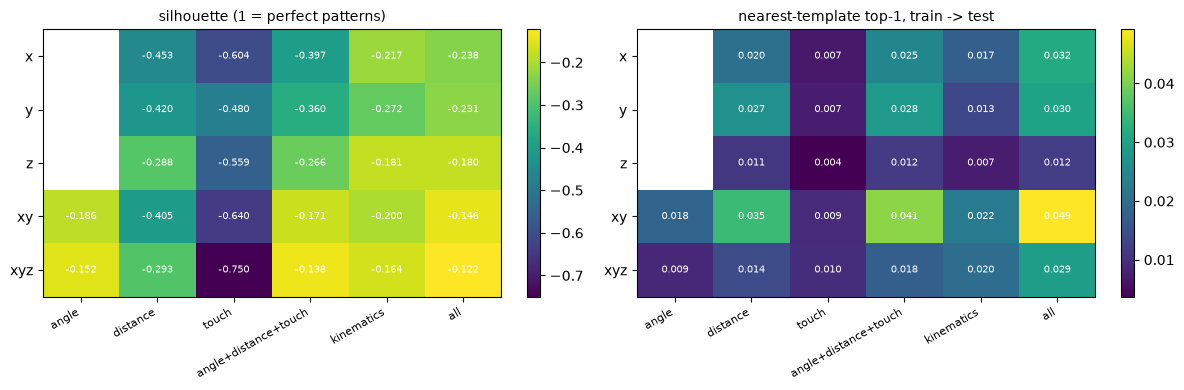

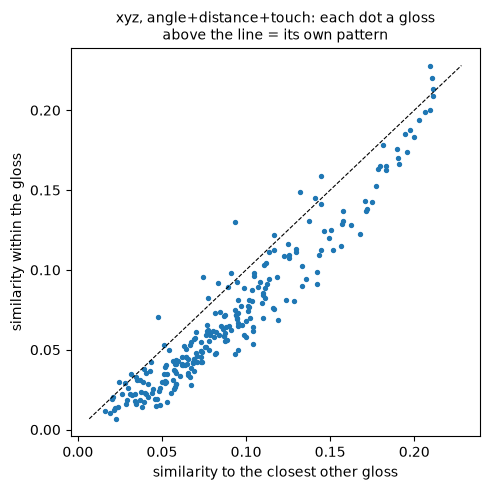

In [6]:
# ============================================================
# Silhouette + template accuracy per axis setting x family; per-gloss intra vs rival
# ============================================================
RES = pd.read_csv(OUT / "results.csv")
d = RES[RES.hand == "dominant"]
fams = list(FAMILY_SETS)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in ((axs[0], "silhouette", "silhouette (1 = perfect patterns)"),
                          (axs[1], "top1", "nearest-template top-1, train -> test")):
    M = d.pivot(index="axes", columns="family", values=metric).reindex(index=list(AXES), columns=fams)
    im = ax.imshow(M.to_numpy(dtype=float), cmap="viridis", aspect="auto")
    ax.set_xticks(range(len(fams)), fams, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(len(AXES)), AXES)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            v = M.iat[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7, color="w")
    ax.set_title(title, fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.04)
fig.tight_layout()
fig.savefig(ASSETS / "grid.png", dpi=130)
plt.show()

PG = pd.read_csv(OUT / "per_gloss.csv")
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(PG.nearest_inter, PG.intra, s=8)
lim = [min(PG.nearest_inter.min(), PG.intra.min()), max(PG.nearest_inter.max(), PG.intra.max())]
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlabel("similarity to the closest other gloss")
ax.set_ylabel("similarity within the gloss")
ax.set_title("xyz, angle+distance+touch: each dot a gloss\nabove the line = its own pattern", fontsize=10)
fig.tight_layout()
fig.savefig(ASSETS / "per_gloss.png", dpi=130)
plt.show()

## 7. Patterns per phonological parameter (research follow-up B1 + B2, 2026-09-25)

§§2–6 found no pattern per **sign**. Signs are built from a small, reused set of phonological parameters:
handshape, location, movement, palm orientation (plus one- vs two-handed). So the question moves down
one level: do clips group by the **value of a parameter** (e.g. major location = Head) *across different
signs*?

- **New variables** (`sb.recognize.patterns.phonology_descriptors`), one family per parameter:
  - **handshape**: 15 finger flexion angles, fingertip distances, spread, thumb–index gap (mean / std /
    change over the sign);
  - **orientation**: palm normal and pointing direction;
  - **location**: distance to nose, chin, forehead, mouth, shoulder, chest and the other hand;
  - **movement**: path, net displacement, straightness, extent, reversals, turning, speed;
  - **signtype**: hand presence, inter-hand distance and velocity correlation.

  The left hand is computed mirrored, so relabeling to the dominant hand is exact.
- **Ground truth**: ASL-LEX 2.0 codes (`sb.recognize.aslex`, CC BY-NC 4.0). 229 of 250 glosses map: 209
  exact, 20 same-sign synonyms. A parameter counts for a gloss only when all of its ASL-LEX variants agree.
- **Test** (`parameter_test`), every score **gloss-disjoint**, so a template never contains the sign it
  is tested on:
  - leave-one-gloss-out nearest value template at the gloss level (balanced accuracy vs chance and vs 200
    label shuffles);
  - the same at the clip level (train templates → test clips of held-out glosses);
  - silhouette by value.

| artifact | path |
|---|---|
| phonology descriptors per chunk | `data/cache/gislr/sign_patterns/descriptors_ph/chunk_<k>.parquet` |
| gloss → ASL-LEX codes | `data/cache/gislr/sign_patterns/aslex_codes.csv` |
| family × parameter results | `data/cache/gislr/sign_patterns/parameter_results.csv` |
| whole-sign test with the new variables | `data/cache/gislr/sign_patterns/results_ph.csv` |

In [7]:
# ============================================================
# Phonology descriptors for every clip (resumable chunks)
# ============================================================
DESC_PH = OUT / "descriptors_ph"
DESC_PH.mkdir(parents=True, exist_ok=True)
todo = [(k, c) for k, c in chunks if not (DESC_PH / f"chunk_{k:03d}.parquet").exists()]
bar = tqdm(total=sum(len(c) for _, c in todo), desc="phonology descriptors")
with ProcessPoolExecutor(WORKERS) as ex:
    for k, c in todo:
        rows = []
        for r in ex.map(PT.file_phonology, [str(DATA / p) for p in c.npz_relpath], chunksize=64):
            rows.append(r)
            bar.update()
        t = pd.DataFrame(rows, index=c.index)
        tmp = DESC_PH / f"chunk_{k:03d}.tmp.parquet"
        t.to_parquet(tmp)
        os.replace(tmp, DESC_PH / f"chunk_{k:03d}.parquet")
bar.close()
PH = pd.concat([pd.read_parquet(p) for p in sorted(DESC_PH.glob("chunk_*.parquet"))]).sort_index()
assert len(PH) == len(CLIPS)
print(PH.shape, {f: int(PH.columns.str.startswith(f"ph|{f}:").sum()) for f in PT.PHONOLOGY_FAMILIES})

phonology descriptors: 0it [00:00, ?it/s]

(94477, 258) {'handshape': 150, 'orientation': 28, 'location': 50, 'movement': 22, 'signtype': 6}


In [8]:
# ============================================================
# GISLR gloss -> ASL-LEX 2.0 codes
# ============================================================
from sb.recognize import aslex as AX

CODES = AX.gloss_codes(sorted(CLIPS.sign.unique()))
CODES.to_csv(OUT / "aslex_codes.csv", index=False)
print(CODES.mapping.value_counts().to_string())
print("\nunmapped:", " ".join(CODES.gloss[CODES.mapping == "unmapped"]))
print("\nglosses with a value, per parameter:\n" + CODES[list(AX.PARAMETERS)].notna().sum().to_string())

mapping
exact       209
unmapped     21
synonym      20

unmapped: beside every eye feet glasswindow goose jeans look mitten nap noisy pajamas police puppy puzzle say shhh shoe sleepy snack wake

glosses with a value, per parameter:
sign_type            208
major_location       214
minor_location       204
contact              211
movement             169
repeated_movement    217
selected_fingers     204
flexion              190
flexion_change       204
spread               129
thumb_position       216
ulnar_rotation       215
handshape            196


In [9]:
# ============================================================
# Family x parameter: does each variable family recover its parameter on unseen signs?
# ============================================================
MIN_GLOSSES = 5  # a value needs >= 5 glosses to be tested
N_PERM = 200
PH = pd.concat([pd.read_parquet(p) for p in sorted(DESC_PH.glob("chunk_*.parquet"))]).sort_index()
TABLE = pd.concat([pd.read_parquet(p) for p in sorted(DESC.glob("chunk_*.parquet"))]).sort_index()
ph = PT.dominant_swap(PH, "ph")[0]
ph = ph[[c for c in ph.columns if c.startswith("ph|")]]
ph.columns = [c[3:] for c in ph.columns]
xy = PT.dominant_swap(TABLE, "xy")[0]
xy = xy[[c for c in xy.columns if c.startswith("xy|")]]
xy.columns = [c[3:] for c in xy.columns]
BOTH = pd.concat([ph, xy.drop(columns=[c for c in xy.columns if c.startswith("meta:")])], axis=1)
FAM_PH = {**{f: (f,) for f in PT.PHONOLOGY_FAMILIES}, "all phonology": PT.PHONOLOGY_FAMILIES,
          "§3 variables (xy)": ("angle", "distance", "touch", "kinematics")}
use = (TABLE["xyz|meta:n_kept"] > 0).to_numpy()
gloss = CLIPS.sign.to_numpy()[use]
is_ref = (CLIPS.split == "train").to_numpy()[use]
codes = CODES.set_index("gloss")
prow = []
for fam, fams in tqdm(FAM_PH.items(), desc="families"):
    X, cols = PT.feature_matrix(BOTH[use], fams)
    for par in AX.PARAMETERS:
        r = PT.parameter_test(X, gloss, is_ref, codes[par].to_dict(), MIN_GLOSSES, n_perm=N_PERM)
        if r is None:
            continue
        prow.append({"family": fam, "parameter": par, "n_vars": len(cols),
                     "values": " / ".join(f"{v} ({n})" for v, n in zip(r["values"], r["glosses_per_value"])),
                     **{k: v for k, v in r.items() if k not in ("values", "glosses_per_value")}})
PRES = pd.DataFrame(prow)
PRES["lift"] = PRES.gloss_bacc / PRES.chance
PRES.to_csv(OUT / "parameter_results.csv", index=False)
best = PRES.loc[PRES.groupby("parameter").gloss_bacc.idxmax()]
print("best family per parameter (gloss-level, leave-one-gloss-out):")
print(best[["parameter", "family", "n_glosses", "chance", "gloss_bacc", "gloss_bacc_null", "p", "clip_bacc",
            "silhouette"]].sort_values("gloss_bacc", ascending=False).to_string(index=False, float_format="{:.3f}".format))

families:   0%|          | 0/7 [00:00<?, ?it/s]

best family per parameter (gloss-level, leave-one-gloss-out):
        parameter            family  n_glosses  chance  gloss_bacc  gloss_bacc_null     p  clip_bacc  silhouette
 selected_fingers         handshape        202   0.167       0.808            0.173 0.000      0.627      -0.068
repeated_movement          movement        217   0.500       0.802            0.495 0.000      0.589       0.021
   ulnar_rotation       orientation        215   0.500       0.751            0.496 0.000      0.592       0.014
   thumb_position         handshape        216   0.500       0.740            0.496 0.000      0.684       0.047
           spread         handshape        129   0.500       0.703            0.500 0.000      0.572       0.007
          contact §3 variables (xy)        211   0.500       0.656            0.499 0.000      0.570       0.007
   major_location     all phonology        210   0.250       0.653            0.249 0.000      0.495       0.004
   flexion_change     all phonolog

In [10]:
# ============================================================
# Whole-sign test again, now with the phonological variables
# ============================================================
tr, te = is_ref, ~is_ref
wrow = []
for fam, fams in {**FAM_PH, "all phonology + §3": PT.PHONOLOGY_FAMILIES + ("angle", "distance", "touch", "kinematics")}.items():
    X, cols = PT.feature_matrix(BOTH[use], fams)
    rep = PT.similarity_report(X[tr], gloss[tr])
    nt = PT.nearest_template(X[tr], gloss[tr], X[te], gloss[te])
    wrow.append({"family": fam, "n_vars": len(cols), **{k: v for k, v in rep.items() if k != "per_gloss"}, **nt})
WRES = pd.DataFrame(wrow)
WRES.to_csv(OUT / "results_ph.csv", index=False)
print(WRES[["family", "n_vars", "intra", "inter", "nearest_inter", "frac_glosses_separable", "silhouette", "top1",
            "top5"]].to_string(index=False, float_format="{:.3f}".format))

            family  n_vars  intra  inter  nearest_inter  frac_glosses_separable  silhouette  top1  top5
         handshape      75  0.298  0.003          0.298                   0.384      -0.164 0.261 0.488
       orientation      14  0.286  0.005          0.309                   0.232      -0.275 0.108 0.296
          location      22  0.341  0.010          0.402                   0.092      -0.396 0.066 0.196
          movement      11  0.114  0.022          0.139                   0.112      -0.276 0.027 0.093
          signtype       3  0.856  0.855          0.899                   0.004      -0.575 0.003 0.020
     all phonology     125  0.285  0.000          0.253                   0.700      -0.086 0.388 0.619
 §3 variables (xy)     111  0.107  0.023          0.125                   0.160      -0.146 0.049 0.163
all phonology + §3     236  0.222  0.003          0.197                   0.724      -0.072 0.365 0.593


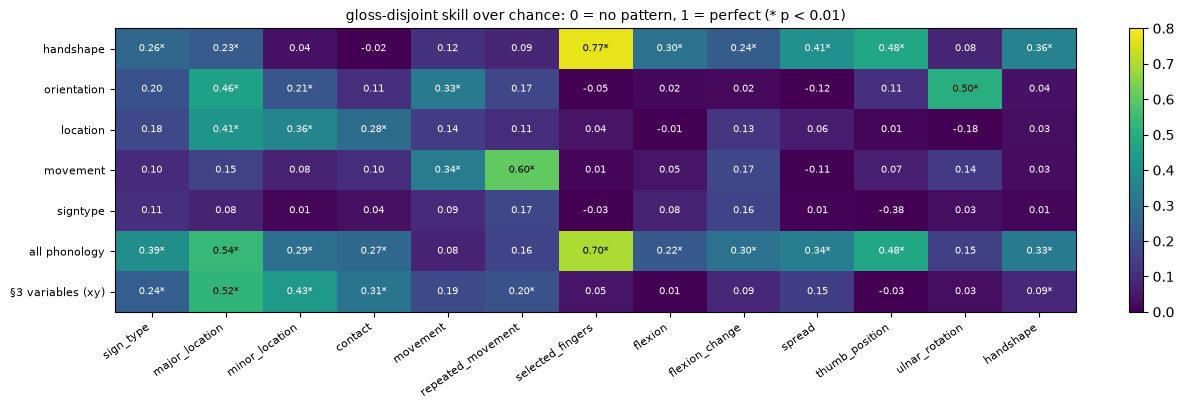

In [11]:
# ============================================================
# Figure: skill = (balanced acc - chance) / (1 - chance), family x parameter (* = p < 0.01 vs 200 label shuffles)
# ============================================================
PRES = pd.read_csv(OUT / "parameter_results.csv")
fams = list(FAM_PH)
pars = [p for p in AX.PARAMETERS if p in set(PRES.parameter)]
PRES["skill"] = (PRES.gloss_bacc - PRES.chance) / (1 - PRES.chance)
L = PRES.pivot(index="family", columns="parameter", values="skill").reindex(index=fams, columns=pars)
Pv = PRES.pivot(index="family", columns="parameter", values="p").reindex(index=fams, columns=pars)
fig, ax = plt.subplots(figsize=(12, 4.2))
im = ax.imshow(L.to_numpy(float), cmap="viridis", aspect="auto", vmin=0, vmax=0.8)
ax.set_xticks(range(len(pars)), pars, rotation=35, ha="right", fontsize=8)
ax.set_yticks(range(len(fams)), fams, fontsize=8)
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        v = L.iat[i, j]
        if np.isfinite(v):
            ax.text(j, i, f"{v:.2f}" + ("*" if Pv.iat[i, j] < 0.01 else ""), ha="center", va="center", fontsize=7,
                    color="w" if v < 0.5 else "k")
ax.set_title("gloss-disjoint skill over chance: 0 = no pattern, 1 = perfect (* p < 0.01)", fontsize=10)
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
fig.savefig(ASSETS / "parameter_grid.png", dpi=130)
plt.show()

## 8. Time order: DTW over per-frame phonology (research follow-up B3, 2026-09-25)

§7's variables are orderless: a clip's mean, spread and change. Here each clip keeps its time course.

- **Sequence** (`sb.recognize.patterns.phonology_sequence`): the dominant hand's per-frame phonology,
  mirrored for left-dominant clips, in 39 channels:
  - handshape: 25 (15 flexion angles, 5 tip distances, 4 spreads, thumb–index gap);
  - orientation: 6 (palm normal, pointing direction);
  - location: 5 (position, distance to nose, chin and chest);
  - other hand: 3.

  Frames where the dominant hand is missing are interpolated in time. Each clip is resampled to 32 steps,
  which normalizes signing speed. Channels are z-scored on `train`, and each family is scaled to equal
  weight.
- **Matching**: `K` exemplars per gloss drawn from `train` (distinct signers where possible, seeded). Each
  `test` clip goes to the gloss of its nearest exemplar. Three distances, same exemplars, same channels:
  - **orderless**: the time average of each channel;
  - **lockstep**: frame-by-frame after resampling, no warping;
  - **DTW**: Sakoe-Chiba band ±4 or ±8 steps (`dtw_distances`, batched on the GPU, checked against a
    naive DTW to 7e-6).

  So the comparison isolates what time order, and then warping, add.

| artifact | path |
|---|---|
| sequences, per chunk | `data/cache/gislr/sign_patterns/sequences/chunk_<k>.npz` |
| one result per configuration (resumable) | `data/cache/gislr/sign_patterns/dtw_parts/<config>.json` |
| summary | `data/cache/gislr/sign_patterns/dtw_results.csv` |
| per-gloss accuracy, best configuration | `data/cache/gislr/sign_patterns/dtw_per_gloss.csv` |

In [12]:
# ============================================================
# Per-frame phonology sequences for every clip (resumable chunks)
# ============================================================
SEQ_LEN = 32
SEQ_DIR = OUT / "sequences"
SEQ_DIR.mkdir(parents=True, exist_ok=True)
seq_fn = partial(PT.file_sequence, length=SEQ_LEN)
n_ch = sum(len(v) for v in PT.SEQ_CHANNELS.values())
todo = [(k, c) for k, c in chunks if not (SEQ_DIR / f"chunk_{k:03d}.npz").exists()]
bar = tqdm(total=sum(len(c) for _, c in todo), desc="sequences")
with ProcessPoolExecutor(WORKERS) as ex:
    for k, c in todo:
        arr = np.full((len(c), SEQ_LEN, n_ch), np.nan, np.float32)
        ok = np.zeros(len(c), bool)
        for i, s in enumerate(ex.map(seq_fn, [str(DATA / p) for p in c.npz_relpath], chunksize=64)):
            if s is not None:
                arr[i], ok[i] = s, True
            bar.update()
        tmp = SEQ_DIR / f"chunk_{k:03d}.tmp.npz"
        np.savez(tmp, seq=arr.astype(np.float16), ok=ok, index=c.index.to_numpy())
        os.replace(tmp, SEQ_DIR / f"chunk_{k:03d}.npz")
bar.close()
parts = [np.load(p) for p in sorted(SEQ_DIR.glob("chunk_*.npz"))]
SEQS = np.concatenate([p["seq"] for p in parts]).astype(np.float32)
SEQ_OK = np.concatenate([p["ok"] for p in parts])
assert len(SEQS) == len(CLIPS) and (np.concatenate([p["index"] for p in parts]) == CLIPS.index.to_numpy()).all()
print(SEQS.shape, f"· clips with a usable dominant hand: {SEQ_OK.mean():.1%}")

sequences: 0it [00:00, ?it/s]

(94477, 32, 39) · clips with a usable dominant hand: 96.3%


In [13]:
# ============================================================
# Exemplar matching: orderless vs lockstep vs DTW, per channel family and K
# ============================================================
import torch

K_MAIN = 20                  # exemplars per gloss for the main comparison
K_SWEEP = (1, 5, 20)         # few-shot sweep on the best distance
SEED = 42
DTW_PARTS = OUT / "dtw_parts"
DTW_PARTS.mkdir(exist_ok=True)
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train = (CLIPS.split == "train").to_numpy() & SEQ_OK
test = (CLIPS.split == "test").to_numpy() & SEQ_OK
mu = np.nanmean(SEQS[train], axis=(0, 1))
sd = np.nanstd(SEQS[train], axis=(0, 1)) + 1e-6
Z = np.nan_to_num((SEQS - mu) / sd)
names = [c for fam in PT.SEQ_CHANNELS.values() for c in fam]
fam_cols = {f: [names.index(c) for c in cs] for f, cs in PT.SEQ_CHANNELS.items()}


def channels(fams):
    cols, w = [], []
    for f in fams:
        cols += fam_cols[f]
        w += [1 / np.sqrt(len(fam_cols[f]))] * len(fam_cols[f])  # each family weighs the same
    return np.array(cols), np.array(w, np.float32)


def exemplars(k, seed):
    rng = np.random.default_rng(seed)
    idx = []
    for g, grp in CLIPS[train].groupby("sign"):
        grp = grp.sample(frac=1, random_state=int(rng.integers(1 << 31)))
        first = grp.drop_duplicates("participant_id")  # distinct signers first
        idx += list(pd.concat([first, grp.drop(first.index)]).index[:k])
    return np.array(sorted(idx))


FAMSETS = {"handshape": ("handshape",), "orientation": ("orientation",), "location": ("location",),
           "all": ("handshape", "orientation", "location", "other_hand")}
CONFIGS = [(fs, dist, K_MAIN) for fs in FAMSETS for dist in ("orderless", "lockstep", "dtw4")] + \
          [("all", d, K_MAIN) for d in ("dtw8", "dtw16", "dtw")]  # band width; "dtw" = unconstrained
BANDS = {"lockstep": 0, "dtw4": 4, "dtw8": 8, "dtw16": 16, "dtw": None}
test_idx = np.flatnonzero(test)


def run(fs, dist, k, per_gloss=False):
    path = DTW_PARTS / f"{fs}_{dist}_k{k}.json"
    if path.exists() and not per_gloss:
        return json.loads(path.read_text())
    cols, w = channels(FAMSETS[fs])
    ex = exemplars(k, SEED)
    X = torch.tensor(Z[:, :, cols] * w, device=dev)
    E, T = X[ex], X[test_idx]
    if dist == "orderless":
        D = torch.cdist(T.mean(1), E.mean(1)) ** 2
    else:
        D = torch.cat([PT.dtw_distances(T[s:s + 512], E, BANDS[dist]) for s in range(0, len(T), 512)])
    res = {"families": fs, "distance": dist, "k": k, "n_exemplars": len(ex), "n_test": len(test_idx),
           **PT.exemplar_nn(D, CLIPS.sign.to_numpy()[ex], CLIPS.sign.to_numpy()[test_idx])}
    if per_gloss:  # per-gloss accuracy + most common wrong answer, for the best configuration
        classes = np.unique(CLIPS.sign.to_numpy()[ex])
        code = torch.as_tensor(np.searchsorted(classes, CLIPS.sign.to_numpy()[ex]), device=dev)
        per = torch.full((len(T), len(classes)), float("inf"), device=dev).scatter_reduce(
            1, code.expand(len(T), -1), D, reduce="amin")
        pred = classes[per.argmin(1).cpu().numpy()]
        truth = CLIPS.sign.to_numpy()[test_idx]
        wrong = pd.Series(pred[pred != truth], index=truth[pred != truth])
        pg = pd.DataFrame({"gloss": truth, "correct": pred == truth}).groupby("gloss").agg(
            acc=("correct", "mean"), n=("correct", "size"))
        pg["top_confusion"] = wrong.groupby(level=0).agg(lambda p: p.value_counts().index[0]).reindex(pg.index)
        pg.assign(config=f"{fs}/{dist}/k{k}").sort_values("acc").to_csv(OUT / "dtw_per_gloss.csv")
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(res))
    os.replace(tmp, path)
    return res


rows = [run(fs, dist, k) for fs, dist, k in tqdm(CONFIGS, desc="configurations")]
best = max((r for r in rows if r["families"] == "all"), key=lambda r: r["top1"])["distance"]
rows += [run("all", best, k) for k in tqdm(K_SWEEP, desc=f"K sweep ({best})") if k != K_MAIN]
pg_path = OUT / "dtw_per_gloss.csv"
if not pg_path.exists() or pd.read_csv(pg_path).config.iat[0] != f"all/{best}/k{K_MAIN}":
    run("all", best, K_MAIN, per_gloss=True)
DRES = pd.DataFrame(rows).drop_duplicates(["families", "distance", "k"])
DRES.to_csv(OUT / "dtw_results.csv", index=False)
print(f"test clips {len(test_idx)} · chance 0.4% · §7.2 orderless per-gloss mean template: 38.8% top-1\n")
print(f"top-1 at K = {K_MAIN} exemplars per gloss:")
print(DRES[DRES.k == K_MAIN].pivot(index="families", columns="distance", values="top1").reindex(list(FAMSETS))
      [["orderless", "lockstep", "dtw4", "dtw8", "dtw16", "dtw"]].to_string(float_format="{:.3f}".format))
print("\nK sweep:\n" + DRES[(DRES.families == "all") & (DRES.distance == best)].sort_values("k")[
    ["k", "n_exemplars", "top1", "top5"]].to_string(index=False, float_format="{:.3f}".format))

configurations:   0%|          | 0/15 [00:00<?, ?it/s]

K sweep (dtw):   0%|          | 0/3 [00:00<?, ?it/s]

test clips 18183 · chance 0.4% · §7.2 orderless per-gloss mean template: 38.8% top-1

top-1 at K = 20 exemplars per gloss:
distance     orderless  lockstep  dtw4  dtw8  dtw16   dtw
families                                                 
handshape        0.246     0.242 0.280   NaN    NaN   NaN
orientation      0.049     0.083 0.100   NaN    NaN   NaN
location         0.033     0.072 0.084   NaN    NaN   NaN
all              0.345     0.368 0.401 0.411  0.415 0.416

K sweep:
 k  n_exemplars  top1  top5
 1          250 0.152 0.325
 5         1250 0.278 0.511
20         5000 0.416 0.668


In [14]:
# ============================================================
# Per gloss: best and worst under the best DTW configuration (all families, K = 20)
# ============================================================
PGD = pd.read_csv(OUT / "dtw_per_gloss.csv")
print(f"configuration {PGD.config.iat[0]} · top_confusion = most common wrong answer")
print(f"median per-gloss accuracy {PGD.acc.median():.3f}; glosses >= 50%: {(PGD.acc >= 0.5).mean():.1%}; "
      f"< 10%: {(PGD.acc < 0.1).mean():.1%}")
print("\nbest:\n" + PGD.sort_values("acc", ascending=False).head(10).to_string(index=False, float_format="{:.2f}".format))
print("\nworst:\n" + PGD.head(10).to_string(index=False, float_format="{:.2f}".format))

configuration all/dtw/k20 · top_confusion = most common wrong answer
median per-gloss accuracy 0.397; glosses >= 50%: 29.6%; < 10%: 0.4%

best:
      gloss  acc  n top_confusion      config
      uncle 0.85 80        stairs all/dtw/k20
   airplane 0.80 79           pig all/dtw/k20
      brown 0.78 80          talk all/dtw/k20
        cow 0.77 78     yesterday all/dtw/k20
callonphone 0.76 75        yellow all/dtw/k20
        gum 0.75 76          look all/dtw/k20
       food 0.75 75          home all/dtw/k20
       shhh 0.74 82         mouse all/dtw/k20
       frog 0.74 78          duck all/dtw/k20
     flower 0.74 77         clown all/dtw/k20

worst:
 gloss  acc  n top_confusion      config
 there 0.10 63          boat all/dtw/k20
  give 0.13 63          gift all/dtw/k20
   why 0.14 71          tree all/dtw/k20
   pen 0.14 78        pencil all/dtw/k20
 mouth 0.14 76          lips all/dtw/k20
    go 0.15 67           wet all/dtw/k20
 touch 0.15 67          snow all/dtw/k20
    on 0.17 72